## 1. Data Understanding: 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load the dataset
dataset = pd.read_csv('updated_ttg_dataset_v2.csv')

## 2. EDA

- Exclude columns LBXTTG and LBXEMA

In [2]:
# Exclude columns LBXTTG and LBXEMA
dataset = dataset.drop(columns=['LBXTTG', 'LBXEMA'])

#### Data Descreptive:


- Check Data Type and descreptive

In [ ]:
# Check the info and data types
print(dataset.info())
# Summary statistics for numerical columns
dataset.describe()

- **Dataset contain 13 variables,** 36 continuios variables and all features are Numericals.
- **Numerical Columns:** year_of_observation, insured_period, residential, building_dimension, building_type, date_of_occupancy, claim.

- **The dataset variables have the following meaning:**
    - sd

#### Distribution: 

- Features Destribution

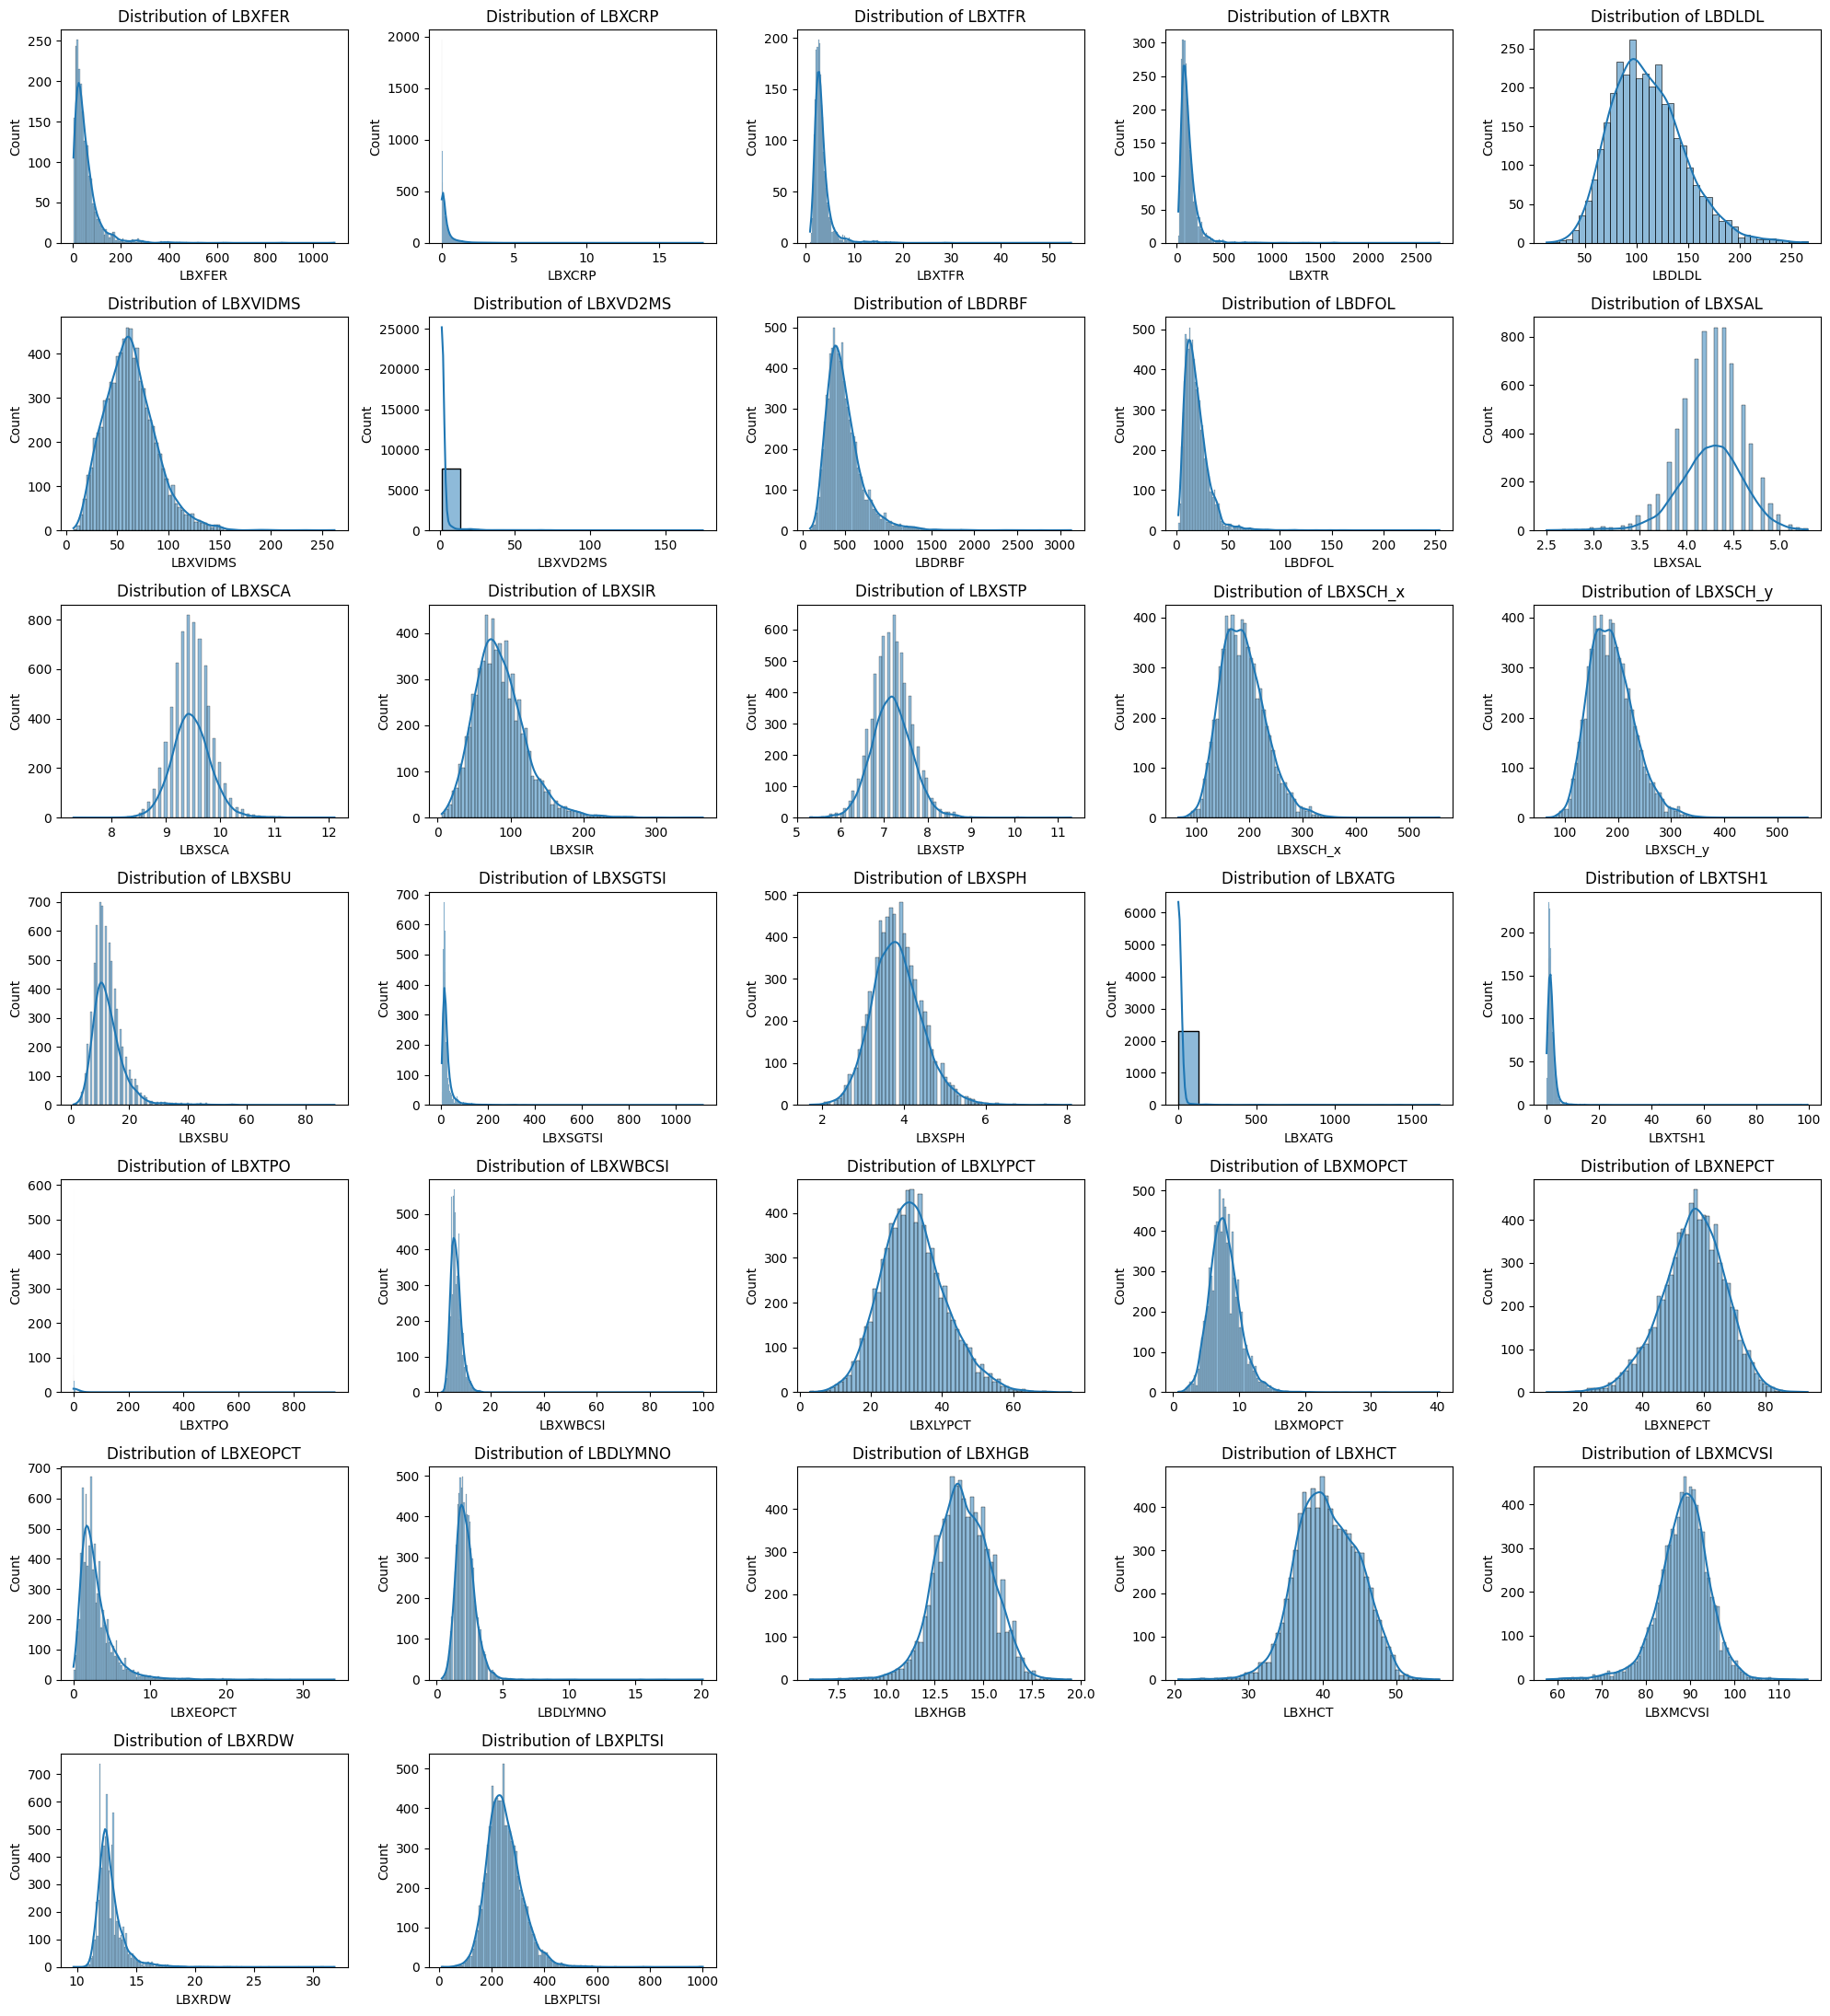

In [6]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Plot feature distributions
def plot_feature_distributions(data):
    plt.figure(figsize=(20, 22))
    for i, column in enumerate(data.columns, 1):
        if column == 'SEQN' or column == 'Class':
            continue
        plt.subplot(7, 5, i-1)
        sns.histplot(data[column], kde=True)
        plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

plot_feature_distributions(dataset)

- DISTRIBUTION INTERPRETATION: 
    - As you can see from the distribution graph for each features, the range of data is diffrent between features.     
    - Thus, the features should be `Standerize` or `Normalize` before modeling.

#### Univariate Correlation:

- This involve to check the interactive between target and features

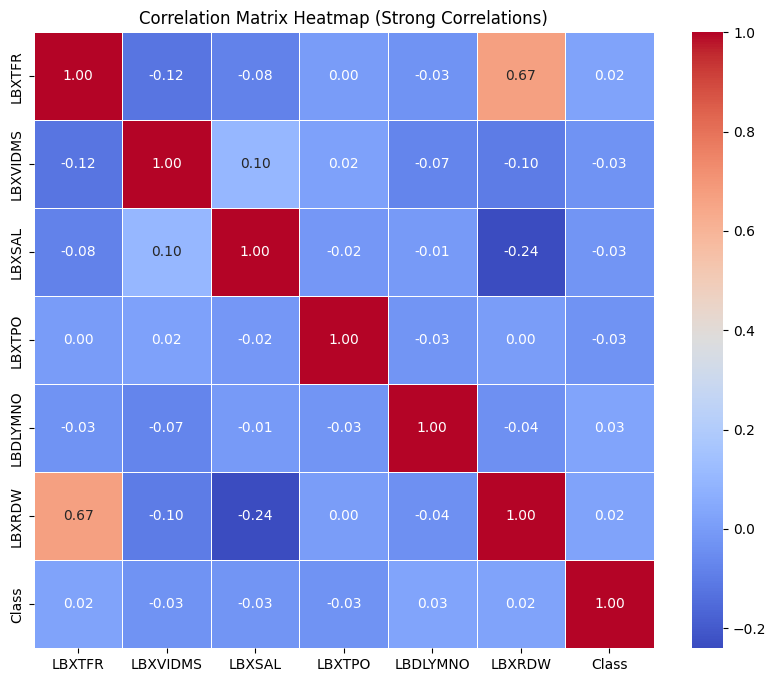

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the threshold for strong correlation
threshold = 0.02
target = 'Class'  # Replace with your target variable name

# Step 1: Compute the correlation matrix
correlation_matrix = dataset.corr()

# Filter the correlation matrix to only include strong correlations with the target
strong_corr_features = correlation_matrix.index[correlation_matrix[target].abs() >= threshold].tolist()

# Filter the correlation matrix to only include these features
filtered_corr_matrix = correlation_matrix.loc[strong_corr_features, strong_corr_features]

# Visualize the filtered correlation matrix
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(filtered_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap (Strong Correlations)')
plt.show()

#### Multivariate Correlation: 

- This part describe and show the correlation between independent features.

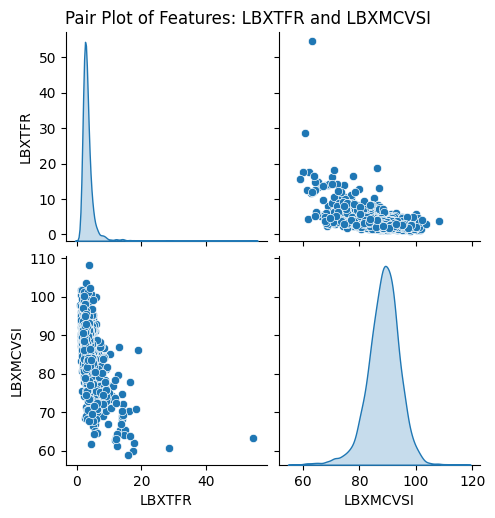

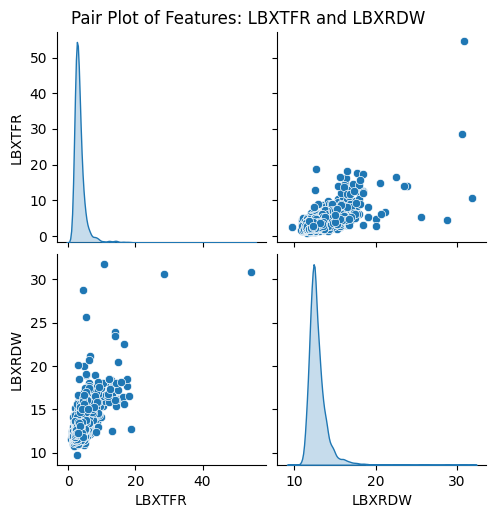

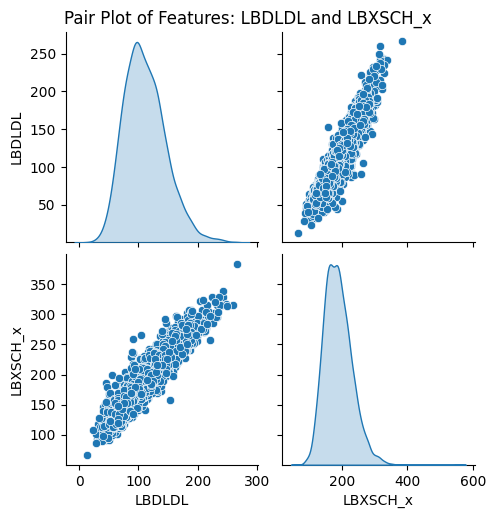

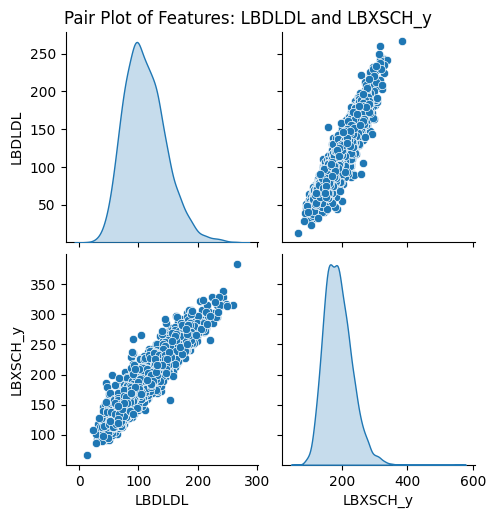

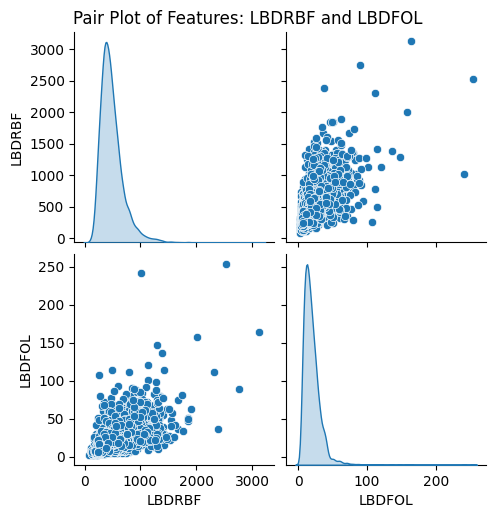

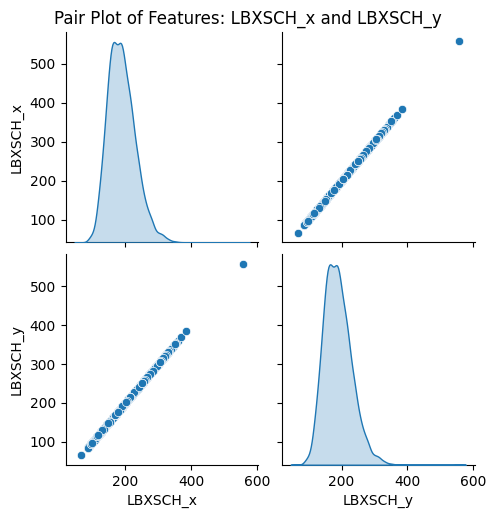

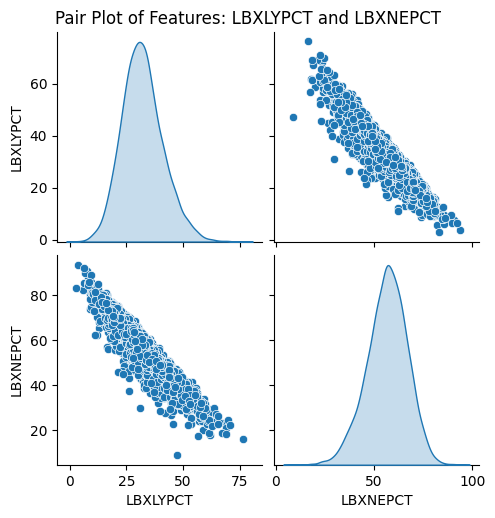

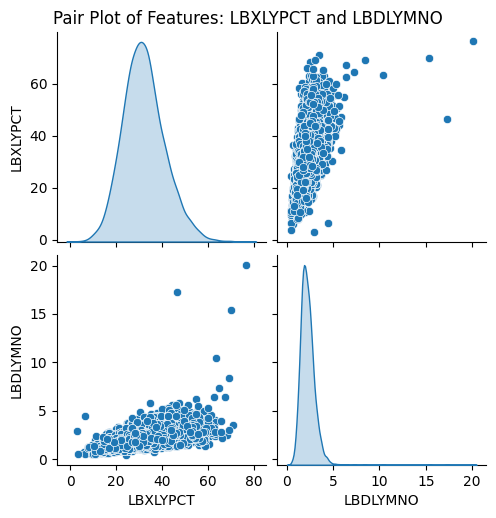

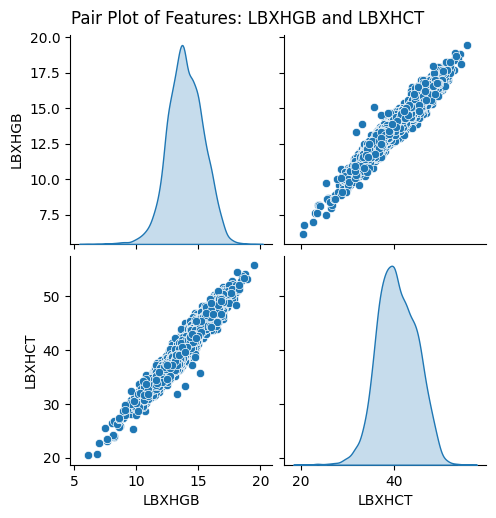

In [5]:
import warnings
warnings.filterwarnings('ignore')

# Calculate the correlation matrix
correlation = dataset.corr().abs()

# Define a threshold for correlations
threshold = 0.5

# Filter correlations based on the threshold
high_correlation_vars = np.where(correlation >= threshold)
high_correlation_pairs = [(correlation.index[x], correlation.columns[y]) for x, y in zip(*high_correlation_vars) if x != y and x < y]

# Plot multivariate distributions for high correlations using pair plots
def plot_high_correlation_pairs(data, pairs):
    for pair in pairs:
        sns.pairplot(data[list(pair)], diag_kind='kde')
        plt.suptitle(f'Pair Plot of Features: {pair[0]} and {pair[1]}', y=1.02)
        plt.show()

plot_high_correlation_pairs(dataset, high_correlation_pairs)

## 3. Data Preparation:

#### Spliting Dataset: 

In [3]:
from sklearn.model_selection import train_test_split

features = dataset.drop(columns=['Class'])
target = dataset['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

#### Missing Imputation: 

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer

if np.isnan(y_train).sum() ==0 and np.isnan(X_train).sum() ==0:
    print("There no missing values in the dataset")
else: 
    feature_imputer = KNNImputer(n_neighbors=2)
    X_train = feature_imputer.fit_transform(X_train)

    target_imputer = KNNImputer(n_neighbors=2)
    y_train = target_imputer.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    print("Missing values have been imputed")
    #y_train = target_imputer.fit_transform(y_train)

Missing values have been imputed


- Method to impute 

#### Class Imbalance: 

In [5]:
from imblearn.over_sampling import SMOTE

# Ensure y_train is categorical
if np.issubdtype(y_train.dtype, np.number):
    y_train = y_train.astype(int)

oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

for c in np.unique(y_train):
    print('{%d : %d}' % (c, sum(y_train==c)))

{1 : 6193}
{2 : 6193}
{3 : 6193}


- Method to manage 

## 4. Modeling

### Select and Evaluate Models:

- **MODEL SELECTION:**
    - **For Baseline Model:** Select `LogisticRegression` model as baseline model.
    - **For Improved Model:** While use `EnsambleingStaking` with two weak classifier (RandomForest and LogisticRegression) as improved model.
    
- **TRAINING AND EVALUATION MODELS:**
    - Cross-Validation strategy: Apply k-fold `cross-validation` to reduce variance and ensure robust model performance.
    - Use *cross-validation* to assess how well the model generalizes to unseen data
        
   

In [6]:
from sklearn.metrics import recall_score

def predict(model):
    # Train the model
    model.fit(X_train, y_train)

    #y_val_filled = y_val.copy()
    if np.isnan(y_test).any():
        missing_indices = y_test.index[y_test.isna()]   # Get the missing indices
        #pipline_model_baseline.fit(X_train, y_train)  # Train the model on the entire training set
        predictions = model.predict(X_test.loc[missing_indices])  # Predict on the rows with missing target values
        y_test.loc[missing_indices] = predictions   # Assign the predictions to the corresponding missing indice

    # Make predictions
    y_pred = model.predict(X_test)
    acc = recall_score(y_test, y_pred, average='macro')

    return acc, y_pred

In [15]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, auc, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

k_folds = KFold(n_splits=3, shuffle=True, random_state=42)

# BASELINE MODEL: Logistic Regression ------------------------------------------------------------------
lr_model = Pipeline([("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("classifier", LogisticRegression( max_iter=100))])
lr_model_recall, lr_model_y_pred = predict(lr_model)
#lr_scores = cross_val_score(lr_model, X_train, y_train, scoring='recall_macro', cv=k_folds)
print(f'The Recall evaluation of Baseline model(Logistic Regression): ', round((lr_model_recall),3))

# IMPROVED MODEL:  Staking Model with Random Forest and SVM as base models --------------------------------
rf_model = SVC(random_state=42)   # Create of instance of SVM model as a a first Weaker classifier
rf_model_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("classifier", rf_model)])

reg_model = LogisticRegression(max_iter=10)  # Create an instance of LogisticRegression model as a second weaker classifier
lr_model_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("classifier", reg_model)])

improved_model = StackingClassifier(estimators=[('rf', rf_model_pipe),
                                                ('svm', lr_model_pipe)],
                                                final_estimator=LogisticRegression(max_iter=10))

improved_model_pipeline = Pipeline([("imputer", KNNImputer(n_neighbors=2)), ("scaler", StandardScaler()), ("classifier", improved_model)])
improved_model_recall, improved_model_y_pred = predict(improved_model_pipeline)
print('The Recall evaluation of improved model(Stacking model): ', round(improved_model_recall,3))

#improved_scores = cross_val_score(improved_model, X_train, y_train, scoring='recall_macro', cv=k_folds)
#print('The Recall evaluation improved model(Stacking model): ', round(improved_scores.mean(),3))


The Recall evaluation of improved model(Stacking model):  0.783


### Model Improvment: 
- **FEATURE SELECTION:** 
    - Use ` RFECV (Recursive feature elimination with cross-validation)` feature selection technique to retain the most relevant features.
    - Then, 


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, recall_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

model = RandomForestClassifier(random_state=42)


# Define the minimum number of features to select
min_features_to_select = 2

scoring = make_scorer(recall_score, average='macro')

# Create the pipeline with RFECV
fs_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('feature_selection', RFECV(estimator=model,
                                step=1,
                                cv=k_folds,
                                scoring=scoring,
                                min_features_to_select=min_features_to_select)),
    ('classification', improved_model)
])

fs_pipeline.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
print("- Evaluation of improved Model:", recall_score(y_test, y_test_predicted))



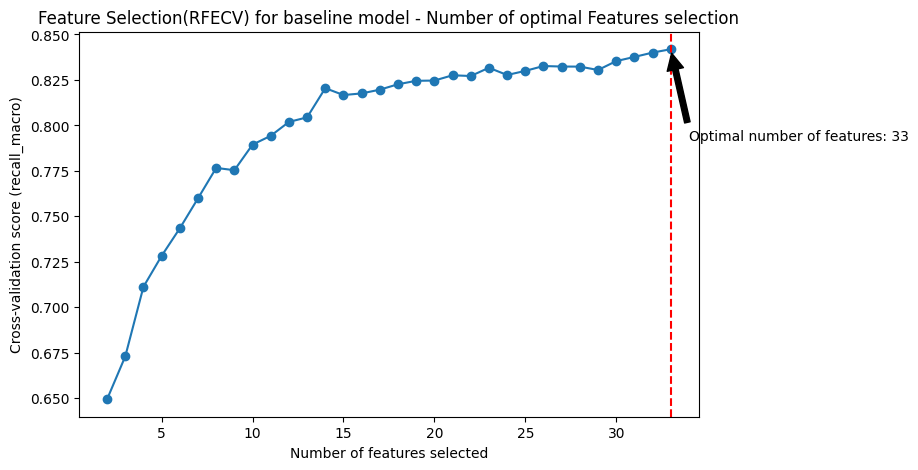

Selected features:
 Index(['SEQN', 'LBXFER', 'LBXCRP', 'LBXTFR', 'LBXTR', 'LBDLDL', 'LBXVIDMS',
       'LBXVD2MS', 'LBDRBF', 'LBDFOL', 'LBXSAL', 'LBXSCA', 'LBXSIR', 'LBXSTP',
       'LBXSCH_x', 'LBXSCH_y', 'LBXSBU', 'LBXSGTSI', 'LBXSPH', 'LBXATG',
       'LBXTSH1', 'LBXTPO', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT',
       'LBXEOPCT', 'LBDLYMNO', 'LBXHGB', 'LBXHCT', 'LBXMCVSI', 'LBXRDW',
       'LBXPLTSI'],
      dtype='object')


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, recall_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3, min_samples_split=2)

scoring = make_scorer(recall_score, average='macro')

min_features_to_select = 2
# Create the pipeline with RFECV
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('feature_selection', RFECV(estimator=model,
                                step=1,
                                cv=k_folds,
                                scoring=scoring,
                                min_features_to_select=min_features_to_select)),
    ('classification', lr_model)
])

pipeline.fit(X_train, y_train)

# Extract the fitted RFECV object
fs_rfecv = pipeline.named_steps['feature_selection']

#print("Optimal number of features : %d" % fs_rfecv.n_features_)

grid_scores = fs_rfecv.cv_results_["mean_test_score"]

fig = plt.figure(figsize=(8, 5))
plt.plot(range(min_features_to_select, len(grid_scores) + min_features_to_select), grid_scores, marker='o')
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (recall_macro)")
plt.title("Feature Selection(RFECV) for baseline model - Number of optimal Features selection")

# Highlight the optimal number of features
optimal_num_features = fs_rfecv.n_features_
plt.axvline(optimal_num_features, color='r', linestyle='--')
plt.annotate(f'Optimal number of features: {optimal_num_features}', 
             xy=(optimal_num_features, max(grid_scores)), 
             xytext=(optimal_num_features + 1, max(grid_scores) - 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

fig.savefig("fs_rfecv.pdf", bbox_inches='tight')
plt.show()

# Get the selected feature names
#X_train_ds = pd.DataFrame(X_train, columns=features.columns)
selected_features = features.columns[fs_rfecv.support_]
print("Selected features:\n", selected_features)

### Hyperparameter Tunning:

- For Hypertunning Baseline Model (LogisticRegression)

In [24]:
from sklearn.metrics import recall_score
import optuna

# For feature selection using RFECV 
min_features_to_select = 2
fs_model = RandomForestClassifier(random_state=42, n_estimators=10, max_depth=10, min_samples_split=2)
scoring = make_scorer(recall_score, average='macro')

def objective(trial):
    # suggest hyperparameters for Logistic Regression
    #C = trial.suggest_loguniform('C', 1e-10, 1e10)
    max_iter = trial.suggest_int('max_iter', 150, 250)
    
    model = LogisticRegression(max_iter=max_iter)
    
    # For cross-validation
    k_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    # Create a pipeline
    model_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=2)),
                           ("scaler", StandardScaler()), 
                               ('feature_selection', RFECV(estimator=fs_model,
                                step=1,
                                cv=k_folds,
                                scoring=scoring,
                                min_features_to_select=min_features_to_select)),
                           ("classifier", model)])
    
    # Evaluate the model using cross-validation
    k_folds = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model_pipe, X_train, y_train, scoring='recall_macro', cv=k_folds)

    # Fit the model
    model_pipe.fit(X_train, y_train)

    #y_val_filled = y_val.copy()
    if np.isnan(y_test).any():
        missing_indices = y_test.index[y_test.isna()]   # Get the missing indices
        #pipline_model_baseline.fit(X_train, y_train)  # Train the model on the entire training set
        predictions = model_pipe.predict(X_test.loc[missing_indices])  # Predict on the rows with missing target values
        y_test.loc[missing_indices] = predictions   # Assign the predictions to the corresponding missing indice
    
    # Calculate the recall score
    y_test_predicted = model_pipe.predict(X_test)
    recall = recall_score(y_test, y_test_predicted, average='macro')

    return round(recall, 3)

# Create a study and optimize Baseline Model
base_model_tunning = optuna.create_study(direction='maximize')
base_model_tunning.optimize(objective, n_trials=5)
# Print the best hyperparameters and their corresponding accuracy
print("Best hyperparameters for Improved model: ", base_model_tunning.best_params)

# Refit the model with the best hyperparameters to obtain the selected features
best_max_iter = base_model_tunning.best_params['max_iter']
best_model = LogisticRegression(max_iter=best_max_iter)

# Create the pipeline with the best hyperparameters
best_model_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=2)),
                            ("scaler", StandardScaler()), 
                            ('feature_selection', RFECV(estimator=fs_model,
                                                        step=1,
                                                        cv=k_folds,
                                                        scoring=scoring,
                                                        min_features_to_select=min_features_to_select)),
                            ("classifier", best_model)])

# Fit the pipeline on the entire training set
best_model_pipe.fit(X_train, y_train)

# Extract the selected features fitted RFECV object
fs_rfecv = best_model_pipe.named_steps['feature_selection']
selected_features = features.columns[fs_rfecv.support_]
print("Selected features for the final model: ", selected_features)

[I 2024-10-22 21:09:08,646] A new study created in memory with name: no-name-392d1949-b6d8-476b-9d58-5960f2060fe3


[I 2024-10-22 21:11:58,188] Trial 0 finished with value: 0.775 and parameters: {'max_iter': 232}. Best is trial 0 with value: 0.775.
[I 2024-10-22 21:14:24,362] Trial 1 finished with value: 0.776 and parameters: {'max_iter': 212}. Best is trial 1 with value: 0.776.
[I 2024-10-22 21:16:42,621] Trial 2 finished with value: 0.776 and parameters: {'max_iter': 223}. Best is trial 1 with value: 0.776.
[I 2024-10-22 21:18:38,865] Trial 3 finished with value: 0.777 and parameters: {'max_iter': 152}. Best is trial 3 with value: 0.777.
[I 2024-10-22 21:20:49,022] Trial 4 finished with value: 0.776 and parameters: {'max_iter': 165}. Best is trial 3 with value: 0.777.


Best hyperparameters for Improved model:  {'max_iter': 152}
Selected features for the final model:  Index(['SEQN', 'LBXCRP', 'LBXTFR', 'LBDLDL', 'LBXVIDMS', 'LBXVD2MS', 'LBDFOL',
       'LBXSAL', 'LBXSCA', 'LBXSIR', 'LBXSTP', 'LBXSCH_x', 'LBXSBU',
       'LBXSGTSI', 'LBXSPH', 'LBXTSH1', 'LBXTPO', 'LBXLYPCT', 'LBXMOPCT',
       'LBXNEPCT', 'LBXEOPCT', 'LBDLYMNO', 'LBXHGB', 'LBXHCT', 'LBXRDW',
       'LBXPLTSI'],
      dtype='object')


- For hyperparameter Improved model (Staking Model)

In [23]:

# For feature selection using RFECV 
min_features_to_select = 5
fs_model = RandomForestClassifier(random_state=42, n_estimators=10, max_depth=3, min_samples_split=5)
scoring = make_scorer(recall_score, average='macro')

# hyperparameter tuning for the improved model
def objective(trial):
    # suggest hyperparameters for SVM and Logistic Regression
    svc_C = trial.suggest_float("svc_C", 0.1, 10.0)  # Regularization for SVM
    lr_max_iter = trial.suggest_int("lr_max_iter", 10, 100)     # Max iterations for Logistic Regression
    
    # Create SVM and Logistic Regression models with trial-specific parameters
    svm_model = SVC(C=svc_C, random_state=42, gamma='auto')
    svm_model_pipe = Pipeline([("scaler", StandardScaler()), ("classifier", svm_model)])

    lr_model = LogisticRegression(max_iter=lr_max_iter, random_state=42)
    lr_model_pipe = Pipeline([("scaler", StandardScaler()), ("classifier", lr_model)])

    improved_model = StackingClassifier(estimators=[('rf', svm_model_pipe),
                                                ('svm', lr_model_pipe)],
                                                final_estimator=LogisticRegression())
    
    # For cross-validation
    k_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    # Create a pipeline
    model_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=2)),
                           ("scaler", StandardScaler()), 
                               ('feature_selection', RFECV(estimator=fs_model,
                                step=1,
                                cv=k_folds,
                                scoring=scoring,
                                min_features_to_select=min_features_to_select)),
                           ("classifier", improved_model)])
    
    # Evaluate the model using cross-validation
    k_folds = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model_pipe, X_train, y_train, scoring='recall_macro', cv=k_folds)

    # Fit the model
    model_pipe.fit(X_train, y_train)

    #y_val_filled = y_val.copy()
    if np.isnan(y_test).any():
        missing_indices = y_test.index[y_test.isna()]   # Get the missing indices
        #pipline_model_baseline.fit(X_train, y_train)  # Train the model on the entire training set
        predictions = model_pipe.predict(X_test.loc[missing_indices])  # Predict on the rows with missing target values
        y_test.loc[missing_indices] = predictions   # Assign the predictions to the corresponding missing indice
    
    # Calculate the recall score
    y_test_predicted = model_pipe.predict(X_test)
    recall = recall_score(y_test, y_test_predicted, average='macro')

    return round(recall, 3)

# Create a study and optimize Improved Model
improved_model_tunning = optuna.create_study(direction='maximize')
improved_model_tunning.optimize(objective, n_trials=5)
print("Best hyperparameters for Improved model: ", improved_model_tunning.best_params) # Print the best hyperparameters and their corresponding accuracy

[I 2024-10-22 20:54:25,493] A new study created in memory with name: no-name-bf219b3b-8c0b-4ccf-9b7b-33cdb08caf2c
[I 2024-10-22 20:56:37,423] Trial 0 finished with value: 0.771 and parameters: {'svc_C': 0.26748790711562, 'lr_max_iter': 70}. Best is trial 0 with value: 0.771.
[I 2024-10-22 20:58:35,679] Trial 1 finished with value: 0.779 and parameters: {'svc_C': 2.8580163398049714, 'lr_max_iter': 17}. Best is trial 1 with value: 0.779.
[I 2024-10-22 21:01:51,158] Trial 2 finished with value: 0.759 and parameters: {'svc_C': 0.45108088677913816, 'lr_max_iter': 41}. Best is trial 1 with value: 0.779.
[I 2024-10-22 21:04:27,383] Trial 3 finished with value: 0.784 and parameters: {'svc_C': 4.66703984600202, 'lr_max_iter': 39}. Best is trial 3 with value: 0.784.
[I 2024-10-22 21:06:58,795] Trial 4 finished with value: 0.781 and parameters: {'svc_C': 3.808373307053893, 'lr_max_iter': 52}. Best is trial 3 with value: 0.784.


Best hyperparameters for Improved model:  {'svc_C': 4.66703984600202, 'lr_max_iter': 39}


### Evaluate models on Testing:
- After finalizing the model, evaluate it on the test set to estimate its real-world performance. This is the true performance estimate as the model has never seen this data before
from sklearn.metrics import balanced_accuracy_score

In [31]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

def prediction(model, name="", refit=True):

    model_pipline = Pipeline([("imputer", KNNImputer(n_neighbors=2)),
                                ("scaler", StandardScaler()), 
                                ('feature_selection', RFECV(estimator=fs_model,
                                    step=1,
                                    cv=k_folds,
                                    scoring=scoring,
                                    min_features_to_select=min_features_to_select)),
                            ("classifier", model)])

    model_pipline.fit(X_train, y_train)

    if np.isnan(y_test).any():
        missing_indices = y_test.index[y_test.isna()]   # Get the missing indices
        #pipline_model_baseline.fit(X_train, y_train)  # Train the model on the entire training set
        predictions = model_pipline.predict(X_test.loc[missing_indices])  # Predict on the rows with missing target values
        y_test.loc[missing_indices] = predictions   # Assign the predictions to the corresponding missing indice
    
    # Calculate the recall score
    y_test_predicted = model_pipline.predict(X_test)
    recall = recall_score(y_test, y_test_predicted, average='macro')
    
    return round(recall, 3)


In [32]:
# Create a baseline model
model = LogisticRegression(max_iter=base_model_tunning.best_params['max_iter'])
print("Final Baseline model recall: ", prediction(model, name="baseline"))

# Create an improved model
svm_model = SVC(C=improved_model_tunning.best_params['svc_C'], random_state=42, gamma='auto')
svm_model_pipe = Pipeline([("scaler", StandardScaler()), ("classifier", svm_model)])

lr_model = LogisticRegression(max_iter=improved_model_tunning.best_params['lr_max_iter'], random_state=42)
lr_model_pipe = Pipeline([("scaler", StandardScaler()), ("classifier", lr_model)])

improved_model = StackingClassifier(estimators=[('rf', svm_model_pipe),
                                            ('svm', lr_model_pipe)],
                                            final_estimator=LogisticRegression())
print("Final Improved model recall: ", prediction(improved_model, name="improved"))

Final Baseline model recall:  0.732
Final Improved model recall:  0.738
